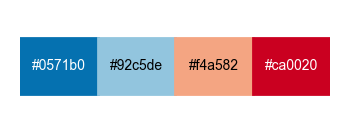

In [51]:
import matplotlib.pyplot as plt

colors = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']
labels = ['#0571b0', '#92c5de', '#f4a582', '#ca0020']

fig, ax = plt.subplots(figsize=(2, 0.6), dpi=200)

for i, (c, lab) in enumerate(zip(colors, labels)):
    # 画色块
    ax.add_patch(plt.Rectangle((i, 0.2), 1, 0.6, color=c))
    
    # 写标签（在色块中间）
    ax.text(i + 0.5, 0.5, lab,
            ha='center', va='center',
            fontsize=5,
            color='white' if i in [0, 3] else 'black')  # 深色用白字更清晰

ax.set_xlim(0, len(colors))
ax.set_ylim(0, 1)
ax.axis('off')

plt.show()

In [52]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2


In [53]:
def is_valid_ec_number(ec_number):
    # 使用正则表达式匹配四位格式的EC号
    pattern = r"^\d+\.\d+\.\d+\.\d+$"
    return bool(re.match(pattern, ec_number))
# 测试示例
print(is_valid_ec_number("1.1.1.1"))  # 输出: True
print(is_valid_ec_number("2.7.1"))    # 输出: False

def read_fasta(fasta_file):
    fasta_dict = {}
    with open(fasta_file, 'r') as f:
        sequence_id = None
        sequence = []
        
        for line in f:
            line = line.strip()
            if line.startswith(">"):  # 识别序列ID
                if sequence_id:  # 之前的序列存入字典
                    fasta_dict[sequence_id] = "".join(sequence)
                sequence_id = line[1:].split()[0]  # 提取序列ID
                sequence = []  # 清空序列缓存
            else:
                sequence.append(line)

        # 存入最后一条序列
        if sequence_id:
            fasta_dict[sequence_id] = "".join(sequence)
    return fasta_dict

import requests
from Bio import pairwise2

def get_uniprot_sequence(entry):
    url = f"https://rest.uniprot.org/uniprotkb/{entry}.fasta"
    response = requests.get(url)
    if response.status_code == 200:
        fasta_lines = response.text.split("\n")
        return "".join(fasta_lines[1:])  # 跳过第一行ID，只拼接序列
    else:
        return None

def sequence_similarity(seq1, target_sequence, method="global"):
    if method == "global":
        alignments = pairwise2.align.globalxx(seq1, target_sequence)
    elif method == "local":
        alignments = pairwise2.align.localxx(seq1, target_sequence)
    else:
        raise ValueError("method 只能是 'global' 或 'local'")

    # 获取最优比对
    best_alignment = alignments[0]
    aligned_seq1, aligned_seq2, score, _, _ = best_alignment

    # 计算相似性：匹配字符数 / 序列长度
    matches = sum(aa1 == aa2 for aa1, aa2 in zip(aligned_seq1, aligned_seq2) if aa1 != '-' and aa2 != '-')
    # similarity = matches / max(len(seq1), len(seq2))  # 归一化到 0~1
    similarity = matches / len(target_sequence)  # 归一化到 0~1

    return similarity

def get_fasta_with_entry_headers(taxonomy_id, output_file="cleaned_sequences.fasta"):
    base_url = "https://rest.uniprot.org/uniprotkb/stream"
    params = {
        "query": f"taxonomy_id:{taxonomy_id}",
        "format": "fasta",
    }

    response = requests.get(base_url, params=params)

    if response.status_code == 200:
        original_fasta = response.text
        cleaned_fasta_lines = []
        
        for line in original_fasta.splitlines():
            if line.startswith(">"):
                # 提取 sp| 或 tr| 后面的 Entry ID
                match = re.match(r">(?:sp|tr)\|(\w+)\|", line)
                if match:
                    cleaned_fasta_lines.append(f">{match.group(1)}")  # 仅保留 Entry ID
            else:
                cleaned_fasta_lines.append(line)  # 保留序列部分
        
        cleaned_fasta = "\n".join(cleaned_fasta_lines)

        # 保存到文件
        with open(output_file, "w") as f:
            f.write(cleaned_fasta)
        
        print(f"清理后的 FASTA 文件已保存: {output_file}")
        return cleaned_fasta
    else:
        print(f"获取 UniProt 数据失败，HTTP 状态码: {response.status_code}")
        return None
    
def get_ncbiID_list(strain_name, AGORA2_strainlist):
    ncbiID_list = []
    tmp_df = AGORA2_strainlist[AGORA2_strainlist['MicrobeID'].str.contains(strain_name)]
    for IDlink in tmp_df['Genome link']:
        ncbiID_list.append(IDlink.split('/')[-1])
    return ncbiID_list

# strain_name = 'Bacteroides_dorei_CL03T12C01'
# get_ncbiID_list(strain_name, AGORA2_strainlist)

def get_stain_family(strain_name, AGORA2_strainlist):#################
    family_list = []
    tmp_df = AGORA2_strainlist[AGORA2_strainlist['MicrobeID'].str.contains(strain_name)]
    for IDlink in tmp_df['Family']:
        family_list.append(IDlink.split('/')[-1])
    return family_list  
# strain_name = 'Bacteroides_dorei_CL03T12C01'
# get_stain_family(strain_name, AGORA2_strainlist)

True
False


# input and output

In [54]:
case_file = '../../Data/Drug/drug_degradable.xlsx'
AGORA2_strainlist_file = '../../Data/AGORA2_strainlist.xlsx'

# strain list

In [55]:
case_df = pd.read_excel(case_file,sheet_name='Sheet2')
case_df = case_df[~case_df['ECnumber'].isna()]
case_df['taxonomy id'] = case_df['taxonomy id'].apply(lambda x: str(int(x)) if pd.notna(x) else "")
case_strain_list = case_df['strain in AGORA2'].dropna().tolist()
case_strain_list = list(set(case_strain_list))
case_strain_list
case_df

,drug,drug_smiles,product_smiles,ECnumber,strain(),strain in AGORA2,protein ID,protein ID in AGORA2,taxonomy id
0,5-ASA,NC1=CC(C(O)=O)=C(O)C=C1,CC(=O)NC1=CC(=C(C=C1)O)C(=O)O,2.3.1.5,Phocaeicola dorei CL03T12C01,Bacteroides_dorei_CL03T12C01,I9R3P9,NaN,
1,5-ASA,NC1=CC(C(O)=O)=C(O)C=C1,CC(=O)NC1=CC(=C(C=C1)O)C(=O)O,2.3.1.5,Faecalibacterium duncaniae,NaN,C7H1G6,NaN,411483
2,5-ASA,NC1=CC(C(O)=O)=C(O)C=C1,CC(=O)NC1=CC(=C(C=C1)O)C(=O)O,2.3.1.5,uncultured Oscillibacter sp.,NaN,A0A1C6JPG6,NaN,876091
3,5-ASA,NC1=CC(C(O)=O)=C(O)C=C1,CC(=O)NC1=CC(=C(C=C1)O)C(=O)O,2.3.1.5,Oscillibacter sp. CAG:155,Oscillibacter,R6TIX3,NaN,
4,5-ASA,NC1=CC(C(O)=O)=C(O)C=C1,CC(=O)NC1=CC(=C(C=C1)O)C(=O)O,2.3.1.5,Ruminococcaceae bacterium D16,Ruminococcaceae_bacterium_D16,T5S060,NaN,
5,5-fluorouracil,FC1=CNC(=O)NC1=O,CC(=O)NC1=CC(=C(C=C1)O)C(=O)O,1.3.1.1,Escherichia coli K-12,NaN,P25889,NaN,83333
6,5-fluorouracil,FC1=CNC(=O)NC1=O,C1C(C(=O)NC(=O)N1)F,1.3.1.1,Escherichia coli K-12,NaN,P76440,NaN,83333
8,ampicillin,[H][C@]12SC(C)(C)[C@@H](N1C(=O)[C@H]2NC(=O)[C@...,CC1([C@@H](N[C@H](S1)[C@@H](C(=O)O)NC(=O)[C@@H...,3.5.2.6,Escherichia coli K-12,NaN,P00811,NaN,83333
9,caffeine,CN1C=NC2=C1C(=O)N(C)C(=O)N2C,CN1C=NC2=C1C(=O)NC(=O)N2C,1.14.13.178,Pseudomonas putida,Pseudomonas_putida,H9N289,NaN,
10,chondroitin sulfate A,CC(=O)N[C@@H]1[C@H]([C@H]([C@H](O[C@H]1O)OS(=O...,unknown,4.2.2.5,Bacteroides salyersiae,Bacteroides_salyersiae,NaN,NaN,


In [56]:
AGORA2_strainlist = pd.read_excel(AGORA2_strainlist_file,sheet_name='Table_S1')
# AGORA2_strainlist = AGORA2_strainlist[
#     (AGORA2_strainlist['Strain/species reference'].str.contains('human gut')) |
#     (AGORA2_strainlist['MicrobeID'].str.contains('|'.join(case_strain_list)))
# ]
AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=1351]
AGORA2_strainlist[AGORA2_strainlist['NCBI Taxonomy ID']!=562]
AGORA2_strainlist['Genome_type'] = AGORA2_strainlist['Genome link'].apply(lambda x:x.split('//')[0])
AGORA2_strainlist = AGORA2_strainlist[AGORA2_strainlist['Genome_type']=='ftp:']  
AGORA2_strainlist.head(3)

,MicrobeID,PubSeedID,2 - complete comparative genomics; 1 - certain comparative genomics; 0 - no comparative genomics,Strain,Species,Genus,Family,Order,Class,Phylum,...,Sample Body Site,Sample Body Subsite,Genome Size * assembled,Gene Count * assembled,GC Count * assembled,GC * assembled,CDS Count * assembled,CDS % * assembled,Genome link,Genome_type
0,Abiotrophia_defectiva_ATCC_49176,Abiotrophia defectiva ATCC 49176 (592010.4),2,Abiotrophia defectiva ATCC 49176,Abiotrophia defectiva,Abiotrophia,Aerococcaceae,Lactobacillales,Bacilli,Firmicutes,...,NaN,0.0,2041839.0,2009.0,959280.0,47.0,1950.0,97.06,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
1,Acaricomes_phytoseiuli_DSM_14247,Acaricomes phytoseiuli DSM 14247 (1120917.3),1,Acaricomes phytoseiuli DSM 14247,Acaricomes phytoseiuli,Acaricomes,Micrococcaceae,Micrococcales,Actinomycetia,Actinobacteria,...,0.0,0.0,2419519.0,2387.0,1506904.0,62.0,2326.0,97.44,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:
2,Acaryochloris_marina_MBIC11017,NaN,0,Acaryochloris marina MBIC11017,Acaryochloris marina,Acaryochloris,Acaryochloridaceae,Synechococcales,unclassified Cyanobacteria,Cyanobacteria,...,0.0,0.0,8361599.0,8488.0,3926263.0,47.0,8409.0,99.07,ftp://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000...,ftp:


In [57]:
family_list = list(set(AGORA2_strainlist['Family'].to_list()))
print(len(family_list))
print(family_list)

162
['Alcaligenaceae', 'Treponemataceae', 'Arcobacteraceae', 'Enterococcaceae', 'Oceanospirillaceae', 'Spirosomaceae', 'Dietziaceae', 'Morganellaceae', 'Tissierellaceae', 'Syntrophaceae', 'Bartonellaceae', 'Aeromonadaceae', 'Brevibacteriaceae', 'Moraxellaceae', 'Eubacteriaceae', 'Pelagibacteraceae', 'Xanthomonadaceae', 'Odoribacteraceae', 'Bacillales Incertae Sedis XI', 'Gemmatimonadaceae', 'Veillonellaceae', 'Coriobacteriaceae', 'unclassified Candidatus Melainabacteria', 'Dysgonomonadaceae', 'Bdellovibrionaceae', 'Reyranellaceae', 'Eubacteriales Family XIII. Incertae Sedis', 'Nocardiaceae', 'Peptoniphilaceae', 'Gordoniaceae', 'Streptomycetaceae', 'Enterobacteriaceae', 'Hafniaceae', 'Muribaculaceae', 'Peptococcaceae', 'unclassified Burkholderiales', 'Oxalobacteraceae', 'Shewanellaceae', 'Fusobacteriaceae', 'Dermabacteraceae', 'Gemmataceae', 'Promicromonosporaceae', 'Eggerthellaceae', 'Carnobacteriaceae', 'unclassified Clostridiales', 'Micrococcaceae', 'Atopobiaceae', 'Sphingobacteriace

# Lachnospiraceae
# Ruminococcaceae
# 这两个family对药物的降解能力差 统计ec号下基因数目 ############################

In [58]:
true_family = {}
for index, row in case_df.iterrows():
    strain_name = row['strain in AGORA2']
    ECnumber = row['ECnumber']
    if pd.notna(strain_name) and pd.notna(ECnumber):  # 用 pd.notna() 代替 not pd.isna()
        family_list = list(set(get_stain_family(strain_name,AGORA2_strainlist)))
        print(ECnumber,strain_name,family_list)  
        if ECnumber not in true_family:
            true_family[ECnumber] = []
            true_family[ECnumber]+=family_list
        else:
            true_family[ECnumber]+=family_list
# Enterobacteriaceae
# Enterococcaceae
# Clostridiaceae
true_family = {k:list(set(v)) for k,v in true_family.items()}
true_family

2.3.1.5 Bacteroides_dorei_CL03T12C01 ['Bacteroidaceae']
2.3.1.5 Oscillibacter ['Oscillospiraceae']
2.3.1.5 Ruminococcaceae_bacterium_D16 ['Oscillospiraceae']
1.14.13.178 Pseudomonas_putida ['Pseudomonadaceae']
4.2.2.5 Bacteroides_salyersiae ['Bacteroidaceae']
4.1.1.25 Enterococcus_faecalis_MMH594 ['Enterococcaceae']
3.2.1.23 Klebsiella_pneumoniae ['Enterobacteriaceae']
3.2.1.23 Enterococcus_faecalis ['Enterococcaceae']
3.2.1.31 Bacteroides_vulgatus ['Bacteroidaceae']
3.2.1.31 Escherichia_coli ['Enterobacteriaceae']
3.2.1.31 Escherichia_coli ['Enterobacteriaceae']
3.2.1.31 Escherichia_coli ['Enterobacteriaceae']
3.2.1.31 Escherichia_coli ['Enterobacteriaceae']
3.5.4.1 Escherichia_coli ['Enterobacteriaceae']
1.7.1.6 Escherichia_coli ['Enterobacteriaceae']
1.7.1.6 Clostridium_perfringens ['Clostridiaceae']
1.7.1.6 Escherichia_coli ['Enterobacteriaceae']
1.7.1.16 Clostridium_leptum_DSM_753 ['Oscillospiraceae']
2.4.2.2 Bacteroides_uniformis ['Bacteroidaceae']
2.4.2.2 Bacteroides_thetaiotaom

{'2.3.1.5': ['Oscillospiraceae', 'Bacteroidaceae'],
 '1.14.13.178': ['Pseudomonadaceae'],
 '4.2.2.5': ['Bacteroidaceae'],
 '4.1.1.25': ['Enterococcaceae'],
 '3.2.1.23': ['Enterobacteriaceae', 'Enterococcaceae'],
 '3.2.1.31': ['Enterobacteriaceae', 'Bacteroidaceae'],
 '3.5.4.1': ['Enterobacteriaceae'],
 '1.7.1.6': ['Clostridiaceae', 'Enterobacteriaceae'],
 '1.7.1.16': ['Oscillospiraceae'],
 '2.4.2.2': ['Bacteroidaceae']}

# 统计不同ECnumber在不同family的enzyme counts

In [59]:
# 遍历ec，遍历ec预测结果，统计  
ecnumber_list = case_df['ECnumber'].dropna().tolist()
# ecnumber_list = ['.'.join(x.split('.')[0:3]) for x in ecnumber_list]
ecnumber_list = list(set(ecnumber_list))
ecnumber_list = [x for x in ecnumber_list if x != '1.1.-.-']
ecnumber_list += ['3.1.3.1','3.1.3.2']          
ecnumber_list += ['2.1.1.67','1.17.3.2','1.17.1.4']            #https://www.frontiersin.org/journals/pharmacology/articles/10.3389/fphar.2022.879170/full #硫嘌呤 S-甲基转移酶（Thiopurine S-methyltransferase，TPMT） 
ecnumber_list.remove('1.14.13.178')  ##数据来源不准确
ecnumber_list.remove('2.1.1.67') ##数据来源不准确
ecnumber_list.remove('1.17.3.2') ##数据来源不准确
ecnumber_list.remove('1.17.1.4') ##数据来源不准确

ecnumber_list = [x for x in ecnumber_list if x!='3.1.3.1, 3.1.3.2']
ecnumber_list.remove('1.7.1.16')
ecnumber_list

['3.5.4.5',
 '3.5.2.6',
 '3.2.1.23',
 '3.5.4.1',
 '4.2.2.5',
 '4.1.1.25',
 '3.2.1.31',
 '1.7.1.6',
 '2.4.2.2',
 '1.3.1.1',
 '2.3.1.5',
 '3.1.3.1',
 '3.1.3.2']

In [60]:
strain_eccounts = {}

clean_result_folder = '/home/wuke/project/bio_deeplearning/Z-Benchmark-EC_predict/CLEAN-0205/app/results/'

for index, row in tqdm(AGORA2_strainlist.iterrows(), total=len(AGORA2_strainlist)):
    ncbiID = row['Genome link'].split('/')[-1]  # 提取 NCBI ID
    strain_family = row['Family']
    clean_result_file = os.path.join(clean_result_folder, f"{ncbiID}_clean_result.json")

    if not os.path.exists(clean_result_file):
        continue  # 如果文件不存在，跳过

    with open(clean_result_file, 'r', encoding='utf-8') as f:
        clean_result = json.load(f)

    # 预处理 clean_result：保留前三位的 EC 号
    # clean_result = {k: ['.'.join(x.split('.')[0:3]) for x in v] for k, v in clean_result.items()}

    # 遍历 EC 列表
    for ec in ecnumber_list:
        # ec_prefix = '.'.join(ec.split('.')[0:3])
        ec_prefix = ec
        if ec_prefix not in strain_eccounts:
            strain_eccounts[ec_prefix] = {}
        if strain_family not in strain_eccounts[ec_prefix]:
            strain_eccounts[ec_prefix][strain_family] = 0

        # 检查 clean_result 是否含有目标 EC
        for v in clean_result.values():
            if ec_prefix in v:
                strain_eccounts[ec_prefix][strain_family] += 1


100%|██████████| 6244/6244 [00:30<00:00, 205.37it/s]


In [61]:
print(len(strain_eccounts))
print(len(true_family),true_family)
strain_eccounts

13
10 {'2.3.1.5': ['Oscillospiraceae', 'Bacteroidaceae'], '1.14.13.178': ['Pseudomonadaceae'], '4.2.2.5': ['Bacteroidaceae'], '4.1.1.25': ['Enterococcaceae'], '3.2.1.23': ['Enterobacteriaceae', 'Enterococcaceae'], '3.2.1.31': ['Enterobacteriaceae', 'Bacteroidaceae'], '3.5.4.1': ['Enterobacteriaceae'], '1.7.1.6': ['Clostridiaceae', 'Enterobacteriaceae'], '1.7.1.16': ['Oscillospiraceae'], '2.4.2.2': ['Bacteroidaceae']}


{'3.5.4.5': {'Aerococcaceae': 1,
  'Micrococcaceae': 1,
  'Acaryochloridaceae': 0,
  'Oscillospiraceae': 11,
  'Lachnospiraceae': 27,
  'Sporomusaceae': 0,
  'Alcaligenaceae': 0,
  'Eubacteriales Family XII. Incertae Sedis': 1,
  'Acidaminococcaceae': 3,
  'Acidobacteriaceae': 1,
  'Comamonadaceae': 0,
  'Moraxellaceae': 2,
  'Pasteurellaceae': 35,
  'Actinomycetaceae': 14,
  'Aeromonadaceae': 26,
  'Rhizobiaceae': 3,
  'Rikenellaceae': 10,
  'Peptoniphilaceae': 7,
  'Arcobacteraceae': 0,
  'Bacillaceae': 309,
  'Bacteroidaceae': 51,
  'unclassified Clostridiales': 1,
  'Bifidobacteriaceae': 0,
  'Brachyspiraceae': 0,
  'Bradyrhizobiaceae': 4,
  'Paenibacillaceae': 2,
  'Erysipelotrichaceae': 21,
  'Burkholderiaceae': 10,
  'Campylobacteraceae': 0,
  'Ruminococcaceae': 1,
  'Flavobacteriaceae': 2,
  'Enterobacteriaceae': 1404,
  'Peptostreptococcaceae': 37,
  'Clostridiaceae': 52,
  'Coriobacteriaceae': 1,
  'Corynebacteriaceae': 2,
  'Propionibacteriaceae': 7,
  'Desulfovibrionaceae':

# 标准HGM的family level abundance

In [62]:
#参考文献中的family列表
family_list = [
 'Bifidobacteriaceae',
 'Bacteroidaceae',
 'Porphyromonadaceae',
 'Rikenellaceae',
#  'Enterococcaceae',
 'Streptococcaceae',
 'Turicibacteraceae',
 'Clostridiaceae',
 'Lachnospiraceae',
 'Peptostreptococcaceae',
 'Ruminococcaceae',
 'Veillonellaceae',
 'Erysipelotrichaceae',
 'Alcaligenaceae',
 'Enterobacteriaceae',
 ]

ref1_family_df = pd.read_excel('../../Data/PD_16S_family_level.xlsx')
ref1_family_df['family'] = ref1_family_df['OTU_ID'].apply(lambda x:x.split('f__')[1] if 'f__' in x else '')
ref1_family_df[ref1_family_df['family'].isin(family_list)]

family_list_ratio = {}
for index,row in ref1_family_df.iterrows():
    if row['family'] in family_list:
        family_list_ratio[row['family']] = row['HD1_Feces']

# 按值降序排序
family_list_ratio = dict(sorted(family_list_ratio.items(), key=lambda item: item[1], reverse=True))
print(len(family_list_ratio))
family_list_ratio

14


{'Lachnospiraceae': 0.365819132139,
 'Ruminococcaceae': 0.348432877806,
 'Bacteroidaceae': 0.124035861418,
 'Rikenellaceae': 0.0238380428667,
 'Bifidobacteriaceae': 0.0207618736502,
 'Clostridiaceae': 0.0159797462841,
 'Erysipelotrichaceae': 0.0159253008112,
 'Porphyromonadaceae': 0.0127946861218,
 'Peptostreptococcaceae': 0.0119507812925,
 'Veillonellaceae': 0.00877479537576,
 'Alcaligenaceae': 0.00431026660133,
 'Enterobacteriaceae': 0.000934647284078,
 'Turicibacteraceae': 0.000780385110978,
 'Streptococcaceae': 9.98167002414e-05}

# 结果分析

In [63]:
# 有一个数据不在agora2中，从uniprot中拿基因组，找他的family，然后加过来
if '2.3.1.5' in true_family:
    true_family['2.3.1.5'].append('Oscillospiraceae')  # uniprotID:411483
else:
    true_family['2.3.1.5'] = ['Oscillospiraceae']
    
if '1.3.1.1' in true_family:
    true_family['1.3.1.1'].append('Enterobacteriaceae')  # uniprotID:83333
else:
    true_family['1.3.1.1'] = ['Enterobacteriaceae']    
    
if '3.5.2.6' in true_family:
    true_family['3.5.2.6'].append('Enterobacteriaceae')  # uniprotID:83333
else:
    true_family['3.5.2.6'] = ['Enterobacteriaceae']     
    
if '3.5.4.5' in true_family:
    true_family['3.5.4.5'].append('Enterobacteriaceae')  # uniprotID:83333
else:
    true_family['3.5.4.5'] = ['Enterobacteriaceae']     

# Enterobacteriaceae具有非常强大的代谢能力，主要的药物降解来自于这个，这个菌水平高的患者更容易降解药物
# 找个具体的案例，这个菌丰度高的，药物无效
# 做实验，排名第二的菌，找典型的菌，来降解药物就可以证明。

In [64]:
print(len(strain_eccounts))
print(strain_eccounts)

13
{'3.5.4.5': {'Aerococcaceae': 1, 'Micrococcaceae': 1, 'Acaryochloridaceae': 0, 'Oscillospiraceae': 11, 'Lachnospiraceae': 27, 'Sporomusaceae': 0, 'Alcaligenaceae': 0, 'Eubacteriales Family XII. Incertae Sedis': 1, 'Acidaminococcaceae': 3, 'Acidobacteriaceae': 1, 'Comamonadaceae': 0, 'Moraxellaceae': 2, 'Pasteurellaceae': 35, 'Actinomycetaceae': 14, 'Aeromonadaceae': 26, 'Rhizobiaceae': 3, 'Rikenellaceae': 10, 'Peptoniphilaceae': 7, 'Arcobacteraceae': 0, 'Bacillaceae': 309, 'Bacteroidaceae': 51, 'unclassified Clostridiales': 1, 'Bifidobacteriaceae': 0, 'Brachyspiraceae': 0, 'Bradyrhizobiaceae': 4, 'Paenibacillaceae': 2, 'Erysipelotrichaceae': 21, 'Burkholderiaceae': 10, 'Campylobacteraceae': 0, 'Ruminococcaceae': 1, 'Flavobacteriaceae': 2, 'Enterobacteriaceae': 1404, 'Peptostreptococcaceae': 37, 'Clostridiaceae': 52, 'Coriobacteriaceae': 1, 'Corynebacteriaceae': 2, 'Propionibacteriaceae': 7, 'Desulfovibrionaceae': 0, 'Hafniaceae': 15, 'Eggerthellaceae': 0, 'Enterococcaceae': 738, 'Eu

# 不同EC号在不同family level的enzyme counts

In [65]:
result_value = {'Streptococcaceae':[],
         'Turicibacteraceae':[],
         'Enterobacteriaceae':[],
         'Alcaligenaceae':[],
         'Veillonellaceae':[],
         'Peptostreptococcaceae':[],
         'Porphyromonadaceae':[],
         'Erysipelotrichaceae':[],
         'Clostridiaceae':[],
         'Bifidobacteriaceae':[],
         'Rikenellaceae':[],
         'Bacteroidaceae':[],
         'Ruminococcaceae':[],
         'Lachnospiraceae':[],
         }

# ec_list = []
enzyme_counts_dict_results ={}
for ec, value in strain_eccounts.items():
    sorted_counts = sorted(value.items(), key=lambda x: x[1], reverse=True)
    sorted_dict = dict(sorted_counts)
    sorted_dict = {k:v for k,v in sorted_dict.items() if k in family_list_ratio}
    if ec in true_family:
        print('================',ec,'================')
        print(true_family[ec],len(sorted_dict),sorted_dict)
        # ec_list.append(ec)
        enzyme_counts_dict_results[ec] = sorted_dict
        # for k2,v2 in result_value.items():
        #     if k2 in sorted_dict:
        #         v2.append(sorted_dict[k2])
        #     else:
        #         v2.append(0)
                

================ 3.5.4.5 ================
['Enterobacteriaceae'] 14 {'Enterobacteriaceae': 1404, 'Streptococcaceae': 1087, 'Clostridiaceae': 52, 'Bacteroidaceae': 51, 'Peptostreptococcaceae': 37, 'Lachnospiraceae': 27, 'Erysipelotrichaceae': 21, 'Rikenellaceae': 10, 'Turicibacteraceae': 6, 'Veillonellaceae': 6, 'Porphyromonadaceae': 3, 'Ruminococcaceae': 1, 'Alcaligenaceae': 0, 'Bifidobacteriaceae': 0}
================ 3.5.2.6 ================
['Enterobacteriaceae'] 14 {'Enterobacteriaceae': 16808, 'Streptococcaceae': 5598, 'Clostridiaceae': 501, 'Lachnospiraceae': 437, 'Bacteroidaceae': 396, 'Peptostreptococcaceae': 233, 'Erysipelotrichaceae': 188, 'Bifidobacteriaceae': 128, 'Alcaligenaceae': 108, 'Rikenellaceae': 66, 'Veillonellaceae': 21, 'Turicibacteraceae': 14, 'Ruminococcaceae': 10, 'Porphyromonadaceae': 2}
================ 3.2.1.23 ================
['Enterobacteriaceae', 'Enterococcaceae'] 14 {'Enterobacteriaceae': 2454, 'Bacteroidaceae': 878, 'Streptococcaceae': 427, 'Bifidobac

# 引入abundance*enzyme counts

In [66]:
print(enzyme_counts_dict_results)

{'3.5.4.5': {'Enterobacteriaceae': 1404, 'Streptococcaceae': 1087, 'Clostridiaceae': 52, 'Bacteroidaceae': 51, 'Peptostreptococcaceae': 37, 'Lachnospiraceae': 27, 'Erysipelotrichaceae': 21, 'Rikenellaceae': 10, 'Turicibacteraceae': 6, 'Veillonellaceae': 6, 'Porphyromonadaceae': 3, 'Ruminococcaceae': 1, 'Alcaligenaceae': 0, 'Bifidobacteriaceae': 0}, '3.5.2.6': {'Enterobacteriaceae': 16808, 'Streptococcaceae': 5598, 'Clostridiaceae': 501, 'Lachnospiraceae': 437, 'Bacteroidaceae': 396, 'Peptostreptococcaceae': 233, 'Erysipelotrichaceae': 188, 'Bifidobacteriaceae': 128, 'Alcaligenaceae': 108, 'Rikenellaceae': 66, 'Veillonellaceae': 21, 'Turicibacteraceae': 14, 'Ruminococcaceae': 10, 'Porphyromonadaceae': 2}, '3.2.1.23': {'Enterobacteriaceae': 2454, 'Bacteroidaceae': 878, 'Streptococcaceae': 427, 'Bifidobacteriaceae': 161, 'Lachnospiraceae': 127, 'Clostridiaceae': 119, 'Rikenellaceae': 70, 'Erysipelotrichaceae': 28, 'Ruminococcaceae': 17, 'Peptostreptococcaceae': 16, 'Turicibacteraceae': 16

In [67]:
enzyme_counts_dict_3_results = {
    ec: {family: enzyme_counts * enzyme_counts * enzyme_counts for family, enzyme_counts in enzyme_counts_dict.items()}
    for ec, enzyme_counts_dict in enzyme_counts_dict_results.items()
}
print(enzyme_counts_dict_3_results)

# enzyme_counts_dict_3_results = {
#     ec: {family: enzyme_counts for family, enzyme_counts in enzyme_counts_dict.items()}
#     for ec, enzyme_counts_dict in enzyme_counts_dict_results.items()
# }
# print(enzyme_counts_dict_3_results)

{'3.5.4.5': {'Enterobacteriaceae': 2767587264, 'Streptococcaceae': 1284365503, 'Clostridiaceae': 140608, 'Bacteroidaceae': 132651, 'Peptostreptococcaceae': 50653, 'Lachnospiraceae': 19683, 'Erysipelotrichaceae': 9261, 'Rikenellaceae': 1000, 'Turicibacteraceae': 216, 'Veillonellaceae': 216, 'Porphyromonadaceae': 27, 'Ruminococcaceae': 1, 'Alcaligenaceae': 0, 'Bifidobacteriaceae': 0}, '3.5.2.6': {'Enterobacteriaceae': 4748408986112, 'Streptococcaceae': 175427907192, 'Clostridiaceae': 125751501, 'Lachnospiraceae': 83453453, 'Bacteroidaceae': 62099136, 'Peptostreptococcaceae': 12649337, 'Erysipelotrichaceae': 6644672, 'Bifidobacteriaceae': 2097152, 'Alcaligenaceae': 1259712, 'Rikenellaceae': 287496, 'Veillonellaceae': 9261, 'Turicibacteraceae': 2744, 'Ruminococcaceae': 1000, 'Porphyromonadaceae': 8}, '3.2.1.23': {'Enterobacteriaceae': 14778272664, 'Bacteroidaceae': 676836152, 'Streptococcaceae': 77854483, 'Bifidobacteriaceae': 4173281, 'Lachnospiraceae': 2048383, 'Clostridiaceae': 1685159,

In [68]:
family_abun = {
    'Streptococcaceae': 0.000099,
    'Turicibacteraceae': 0.000780,
    'Enterobacteriaceae': 0.000934,
    'Alcaligenaceae': 0.004310,
    'Veillonellaceae': 0.008774,
    'Peptostreptococcaceae': 0.011950,
    'Porphyromonadaceae': 0.012794,
    'Erysipelotrichaceae': 0.015925,
    'Clostridiaceae': 0.015979,
    'Bifidobacteriaceae': 0.020761,
    'Rikenellaceae': 0.023838,
    'Bacteroidaceae': 0.124035,
    'Ruminococcaceae': 0.348432,
    'Lachnospiraceae': 0.365819
}
import math
family_abun_1_3 = {k: v**(1) for k, v in family_abun.items()}       ##############
print(family_abun_1_3)

{'Streptococcaceae': 9.9e-05, 'Turicibacteraceae': 0.00078, 'Enterobacteriaceae': 0.000934, 'Alcaligenaceae': 0.00431, 'Veillonellaceae': 0.008774, 'Peptostreptococcaceae': 0.01195, 'Porphyromonadaceae': 0.012794, 'Erysipelotrichaceae': 0.015925, 'Clostridiaceae': 0.015979, 'Bifidobacteriaceae': 0.020761, 'Rikenellaceae': 0.023838, 'Bacteroidaceae': 0.124035, 'Ruminococcaceae': 0.348432, 'Lachnospiraceae': 0.365819}


# 计算不同case里面 不同family的abundance*enzyme counts

In [69]:
import math

ec_family_score_matrix = {}

family_order = list(family_abun.keys())  # 🔥 固定顺序来源

for ec, enzyme_counts_dict in enzyme_counts_dict_3_results.items():

    ec_score_dict = {}

    for family in family_order:   # 👈 按固定顺序遍历
        enzyme_counts = enzyme_counts_dict.get(family, 0)  # 没有就0
        abun = family_abun_1_3.get(family, 0)
        score = math.log1p(enzyme_counts * abun)

        ec_score_dict[family] = score

    ec_family_score_matrix[ec] = ec_score_dict

ec_family_score_matrix

{'3.5.4.5': {'Streptococcaceae': 11.753147818094583,
  'Turicibacteraceae': 0.15570375888966256,
  'Enterobacteriaceae': 14.765208020879957,
  'Alcaligenaceae': 0.0,
  'Veillonellaceae': 1.06304866686362,
  'Peptostreptococcaceae': 6.40738043837992,
  'Porphyromonadaceae': 0.29671961059878915,
  'Erysipelotrichaceae': 5.000459866243992,
  'Clostridiaceae': 7.717696220249548,
  'Bifidobacteriaceae': 0.0,
  'Rikenellaceae': 3.212374738525841,
  'Bacteroidaceae': 9.708346179020474,
  'Ruminococcaceae': 0.2989424359264906,
  'Lachnospiraceae': 8.882032865823692},
 '3.5.2.6': {'Streptococcaceae': 16.670103359975776,
  'Turicibacteraceae': 1.1443247055556318,
  'Enterobacteriaceae': 22.212796608064558,
  'Alcaligenaceae': 8.599760473361044,
  'Veillonellaceae': 4.409836505513485,
  'Peptostreptococcaceae': 11.926097975595855,
  'Porphyromonadaceae': 0.09744607896500827,
  'Erysipelotrichaceae': 11.569470261252091,
  'Clostridiaceae': 14.51333888209473,
  'Bifidobacteriaceae': 10.681434707135

In [70]:
ec_family_score_matrix = dict(sorted(ec_family_score_matrix.items()))

In [71]:
ec_family_score_matrix['4.1.1.25']

{'Streptococcaceae': 5.340505058478905,
 'Turicibacteraceae': 0.0,
 'Enterobacteriaceae': 12.332421391919762,
 'Alcaligenaceae': 1.1652486078878268,
 'Veillonellaceae': 1.7033449264434006,
 'Peptostreptococcaceae': 7.484413670362285,
 'Porphyromonadaceae': 0.09744607896500827,
 'Erysipelotrichaceae': 6.774037126061853,
 'Clostridiaceae': 10.019061238798757,
 'Bifidobacteriaceae': 0.020548427549392602,
 'Rikenellaceae': 3.9772878752106604,
 'Bacteroidaceae': 10.481800773511987,
 'Ruminococcaceae': 1.3316945536062916,
 'Lachnospiraceae': 11.01639938244633}

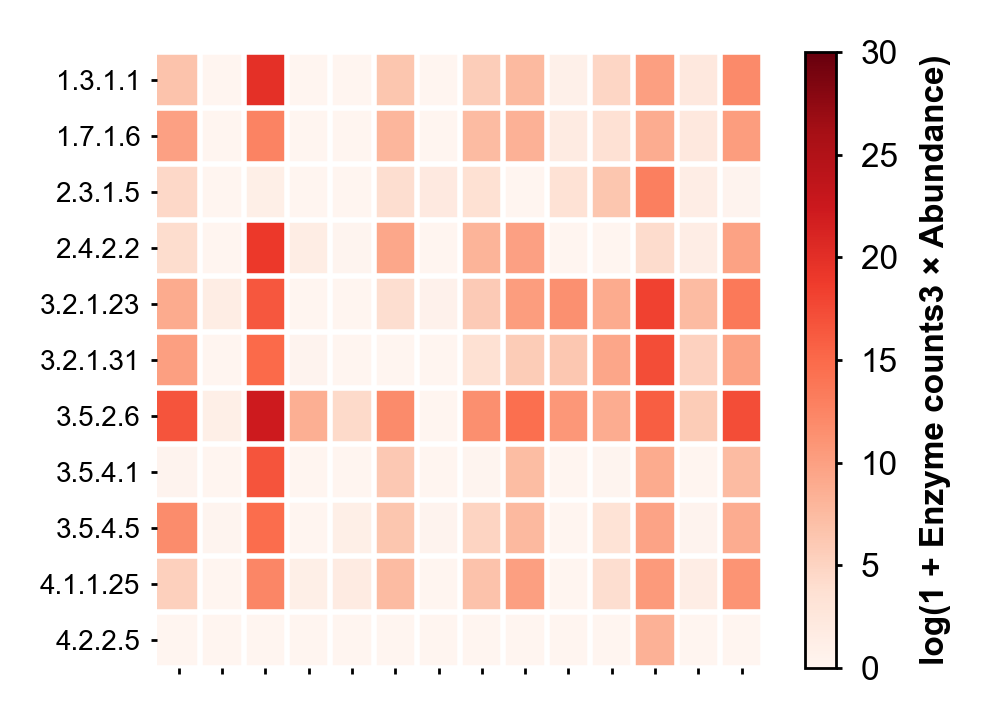

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==== 构建 DataFrame（行=EC，列=family）====
family_order = list(family_abun.keys())  # 固定列顺序
df = pd.DataFrame.from_dict(ec_family_score_matrix, orient='index')
df = df[family_order]   # 双保险锁死顺序

# 如果想 EC 做行、family 做列 → 不用转置
mat = df.values
xlabels = df.columns.to_list()   # family
ylabels = df.index.to_list()     # EC

# ==== 通用绘图设置（完全保留你的风格）====
plt.figure(figsize=(2.2, 2), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(0)
ax.spines['left'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.set_position([0.25, 0.25, 0.7, 0.7])

# ==== 热图主体 ====
im = ax.imshow(mat, cmap='Reds', vmin=0, vmax=30, aspect='auto')
# 如果想固定范围可加 vmin=0, vmax=np.max(mat)

# ==== 颜色条 ====
cbar = plt.colorbar(im, ax=ax, fraction=0.05, pad=-0.05)
cbar.ax.tick_params(direction='out', length=1, width=0.5, labelsize=6)
cbar.set_label('log(1 + Enzyme counts3 × Abundance)', fontsize=6, fontweight='bold')
for spine in cbar.ax.spines.values():
    spine.set_linewidth(0.5)

# ==== 坐标轴刻度 ====
ax.set_xticks(np.arange(mat.shape[1]))
ax.set_yticks(np.arange(mat.shape[0]))

# family 太多一般不显示
ax.set_xticklabels([], fontsize=6)
ax.set_yticklabels(ylabels, fontsize=5)

# ax.set_ylabel("EC number", fontsize=7, fontweight='bold')
ax.set_xlabel("")

# ==== 网格线（论文风）====
for x in range(mat.shape[1] + 1):
    ax.axvline(x + 0.5, color='white', lw=1, zorder=2)
for y in range(mat.shape[0] + 1):
    ax.axhline(y - 0.5, color='white', lw=1, zorder=2)

# ==== 刻度样式 ====
plt.tick_params(axis='y', direction='out', width=0.5, which='both', length=1, pad=2)
plt.tick_params(axis='x', direction='out', width=0.5, which='both', length=1, pad=2)


plt.savefig('../../Figure/Figure-3a1.pdf', dpi=400, bbox_inches='tight')
plt.show()

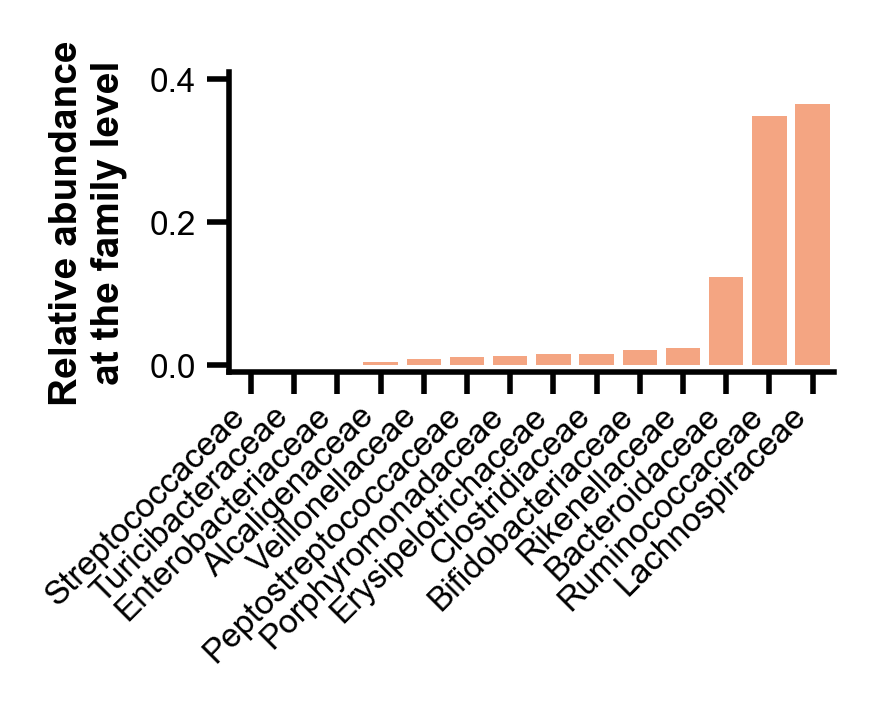

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# === 数据 ===
family_abun = {
    'Streptococcaceae': 0.000099,
    'Turicibacteraceae': 0.000780,
    'Enterobacteriaceae': 0.000934,
    'Alcaligenaceae': 0.004310,
    'Veillonellaceae': 0.008774,
    'Peptostreptococcaceae': 0.011950,
    'Porphyromonadaceae': 0.012794,
    'Erysipelotrichaceae': 0.015925,
    'Clostridiaceae': 0.015979,
    'Bifidobacteriaceae': 0.020761,
    'Rikenellaceae': 0.023838,
    'Bacteroidaceae': 0.124035,
    'Ruminococcaceae': 0.348432,
    'Lachnospiraceae': 0.365819
}

families = list(family_abun.keys())
values = list(family_abun.values())
x_pos = np.arange(len(families))

# ===== 画布 & 样式（沿用你的通用设置）=====
plt.figure(figsize=(2.016, 1), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

ax = plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_linewidth(1)
ax.spines['right'].set_linewidth(0)
ax.set_position([0.2, 0.2, 0.75, 0.75])

# ===== 柱状图 =====
plt.bar(x_pos, values, width=0.8, color='#f4a582', edgecolor='none')
# cmap = ['#8EA9DE','#F7B17E','#F2A198','#A1CD88','#F8F7BF','#C2C1E0']
# ===== 坐标轴 =====
plt.xticks(x_pos, families, rotation=45, fontsize=6,ha='right')
# plt.xticks(range(len(family_abun)),[])
plt.yticks(fontsize=6)

plt.ylabel("Relative abundance\nat the family level", fontsize=7, fontweight='bold')
plt.xlabel("")

plt.tick_params(axis='y', direction='out', width=1, which='both', length=4, pad=2)
plt.tick_params(axis='x', direction='out', width=1, which='both', length=4, pad=1)

plt.ylim(-0.01, 0.41)
plt.xlim(-0.5, len(families) - 0.5)


plt.savefig('../../Figure/Figure-3a2.pdf', dpi=400, bbox_inches='tight')
plt.show()